In [34]:
#1. Data overview
import pandas as pd

# Para ver todas las columnas
pd.set_option('display.max_columns', None)

# Para ver todas las filas
#pd.set_option('display.max_rows', None)

#1.1 Cargar el dataset
df = pd.read_excel("Telco_Churn_EDA.xlsx")

#1.2 Dimensión del dataset
df.shape

(7043, 21)

In [2]:
#1.1 Definir X e y
X = df.drop("Churn Value", axis=1)
y = df["Churn Value"]

In [3]:
#1.2 Train / Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
#1.3 Identificar tipos de variables
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["str"]).columns

In [5]:
#1.4 Crear preprocesado
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
#Numéricas → Escalado
num_transformer = StandardScaler()
#Categóricas → OneHotEncoding
cat_transformer = OneHotEncoder(drop="first", handle_unknown="ignore")
#Combinar
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ]
)



In [6]:
#Para ver como queda el dataset tras el preprocesado.
# 1. Aplicar la transformación
X_transformed = preprocessor.fit_transform(X_train)

# 2. Obtener los nuevos nombres de las columnas (especialmente por el OneHotEncoding)
new_column_names = preprocessor.get_feature_names_out()

# 3. Convertir a DataFrame para que sea legible
X_transformed_df = pd.DataFrame(X_transformed, columns=new_column_names)

# 4. Mostrar las primeras filas
X_transformed_df.head()

,num__Tenure Months,num__Monthly Charges,num__Total Charges,num__CLTV,cat__Gender_Male,cat__Senior Citizen_Yes,cat__Partner_Yes,cat__Dependents_Yes,cat__Phone Service_Yes,cat__Multiple Lines_No phone service,cat__Multiple Lines_Yes,cat__Internet Service_Fiber optic,cat__Internet Service_No,cat__Online Security_No internet service,cat__Online Security_Yes,cat__Online Backup_No internet service,cat__Online Backup_Yes,cat__Device Protection_No internet service,cat__Device Protection_Yes,cat__Tech Support_No internet service,cat__Tech Support_Yes,cat__Streaming TV_No internet service,cat__Streaming TV_Yes,cat__Streaming Movies_No internet service,cat__Streaming Movies_Yes,cat__Contract_One year,cat__Contract_Two year,cat__Paperless Billing_Yes,cat__Payment Method_Credit card (automatic),cat__Payment Method_Electronic check,cat__Payment Method_Mailed check
0,0.102371,-0.521976,-0.262257,-1.372236,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.711743,0.337478,-0.503635,0.194486,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.793155,-0.809013,-0.749883,-1.274104,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-0.263980,0.284384,-0.172722,-0.683623,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
4,-1.281624,-0.676279,-0.989374,-0.842664,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
#1.5 Crear Pipeline modelo base
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [9]:
#1.6 Entrenar modelo
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [10]:
#1.7 Predicciones
# 1. Obtención de etiquetas binarias (0 o 1)
y_pred = pipeline.predict(X_test)
# 2. Obtención de probabilidades estimadas para la clase "Churn" (1)
y_prob = pipeline.predict_proba(X_test)[:,1]

In [11]:
#1.8 Evaluación
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
#8.1 Matriz de Confusión
print(confusion_matrix(y_test, y_pred))

[[917 118]
 [159 215]]


In [12]:
#1.8.2 Reporte de Clasificación
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [13]:
#1.8.3 ROC-AUC
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.8490557751427318


In [86]:
#2.1 Crear modelo Random Forest
from sklearn.ensemble import RandomForestClassifier


In [87]:
#2.2 Pipeline con Random Forest
pipeline_rf = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [88]:
#2.3 Entrenar modelo
pipeline_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [89]:
#2.4 Predicciones
y_pred_rf = pipeline_rf.predict(X_test)
y_prob_rf = pipeline_rf.predict_proba(X_test)[:,1]

In [90]:
#2.5 Evaluacion
#2.5.1 Matriz de Confusión
print(confusion_matrix(y_test, y_pred_rf))


[[942  93]
 [176 198]]


In [91]:
#2.5.2 Reporte de Clasificación
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1035
           1       0.68      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [92]:
#2.5.3 ROC-AUC
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

ROC-AUC: 0.8389650985558914


In [93]:
#2.6 Feature Importance
model = pipeline_rf.named_steps["model"]
importances = model.feature_importances_

In [94]:
#Obtener nombres de variables
feature_names = pipeline_rf.named_steps["preprocessing"].get_feature_names_out()

In [95]:
#Ver top variables
feat_imp = pd.Series(importances, index=feature_names)
feat_imp.sort_values(ascending=False).head(10)

num__Total Charges                      0.156741
num__Tenure Months                      0.152835
num__Monthly Charges                    0.132923
num__CLTV                               0.125180
cat__Internet Service_Fiber optic       0.040130
cat__Dependents_Yes                     0.035685
cat__Payment Method_Electronic check    0.034332
cat__Contract_Two year                  0.031737
cat__Paperless Billing_Yes              0.022657
cat__Gender_Male                        0.022358
dtype: float64

In [96]:
#3.1 Probar distintos thresholds
import numpy as np
from sklearn.metrics import recall_score, precision_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    
    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    
    results.append([t, recall, precision, f1])

In [97]:
#3.2 Ver resultados
results_df = pd.DataFrame(results, columns=["threshold", "recall", "precision", "f1"])
results_df

,threshold,recall,precision,f1
0,0.10,0.946524,0.415493,0.577488
1,0.15,0.893048,0.451351,0.599641
2,0.20,0.860963,0.482036,0.618042
3,0.25,0.799465,0.505068,0.619048
4,0.30,0.743316,0.531549,0.619844
5,0.35,0.716578,0.560669,0.629108
6,0.40,0.668449,0.578704,0.620347
7,0.45,0.628342,0.605670,0.616798
8,0.50,0.574866,0.645646,0.608204
9,0.55,0.500000,0.670251,0.572741


In [98]:
#3.3 Evaluar con nuevo threshold
best_t = 0.35

y_pred_new = (y_prob >= best_t).astype(int)
print(confusion_matrix(y_test, y_pred_new))


[[825 210]
 [106 268]]


In [99]:
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1035
           1       0.56      0.72      0.63       374

    accuracy                           0.78      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.78      0.78      1409



In [100]:
print("ROC-AUC:", roc_auc_score(y_test, y_pred_new))

ROC-AUC: 0.7568394946911571


In [14]:
#4.1 Importaciones
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression


In [ ]:
#4.2 Crear pipeline con SMOTE modelo Regresión Logística
pipeline_smote = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

In [103]:
#4.3 Entrenar modelo
pipeline_smote.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [104]:
#4.4 Predicciones
y_pred_smote = pipeline_smote.predict(X_test)
y_prob_smote = pipeline_smote.predict_proba(X_test)[:,1]

In [105]:
#4.5 Evaluación base (threshold = 0.5)
print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote))

[[761 274]
 [ 84 290]]
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.8467410679686893


In [ ]:
#Probar disntions thresholds
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_prob_smote >= t).astype(int)
    
    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    
    results.append([t, recall, precision, f1])

In [107]:
results_df_smote = pd.DataFrame(results, columns=["threshold", "recall", "precision", "f1"])
print(results_df_smote)

    threshold    recall  precision        f1
0        0.10  0.983957   0.362205  0.529496
1        0.15  0.975936   0.388711  0.555979
2        0.20  0.954545   0.409404  0.573034
3        0.25  0.917112   0.424505  0.580372
4        0.30  0.893048   0.439474  0.589065
5        0.35  0.877005   0.466572  0.609099
6        0.40  0.858289   0.482707  0.617902
7        0.45  0.823529   0.496774  0.619718
8        0.50  0.775401   0.514184  0.618337
9        0.55  0.748663   0.531309  0.621532
10       0.60  0.703209   0.547917  0.615925
11       0.65  0.671123   0.581019  0.622829
12       0.70  0.620321   0.615385  0.617843
13       0.75  0.545455   0.651757  0.593886
14       0.80  0.446524   0.701681  0.545752
15       0.85  0.288770   0.765957  0.419417


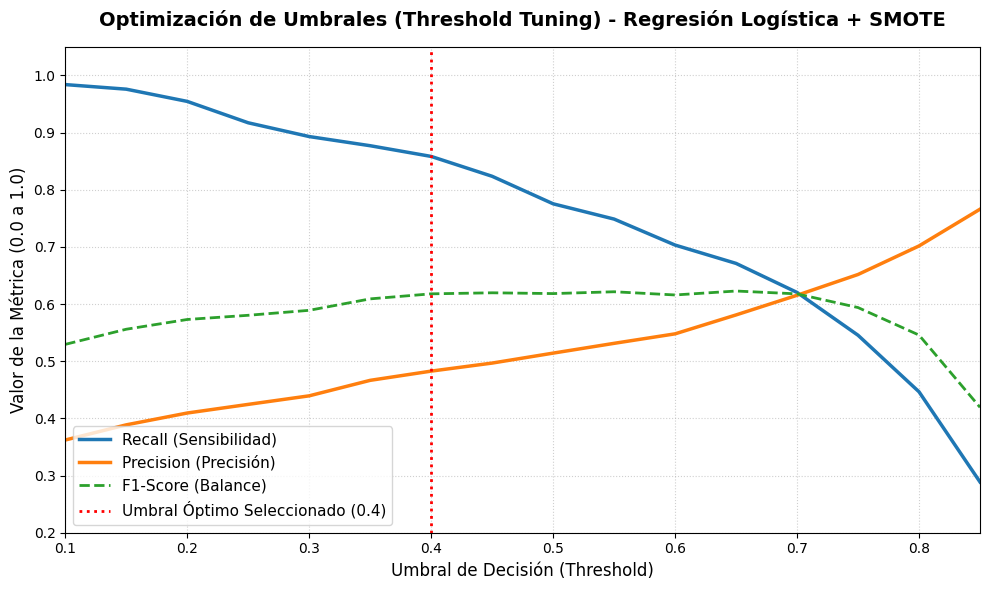

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, f1_score

# 1. Definimos los umbrales a evaluar
thresholds = np.arange(0.1, 0.9, 0.05)

# 2. Función auxiliar para calcular métricas y graficar
def graficar_threshold_tuning(y_true, y_probs, nombre_modelo, umbral_optimo):
    results = []
    
    # Calcular métricas para cada umbral
    for t in thresholds:
        y_pred_t = (y_probs >= t).astype(int)
        recall = recall_score(y_true, y_pred_t)
        precision = precision_score(y_true, y_pred_t)
        f1 = f1_score(y_true, y_pred_t)
        results.append([t, recall, precision, f1])
    
    # Convertir a DataFrame para facilitar el manejo
    df_metrics = pd.DataFrame(results, columns=["threshold", "Recall", "Precision", "F1-Score"])
    
    # Configuración de la gráfica
    plt.figure(figsize=(10, 6))
    plt.plot(df_metrics["threshold"], df_metrics["Recall"], label="Recall (Sensibilidad)", color="#1f77b4", linewidth=2.5)
    plt.plot(df_metrics["threshold"], df_metrics["Precision"], label="Precision (Precisión)", color="#ff7f0e", linewidth=2.5)
    plt.plot(df_metrics["threshold"], df_metrics["F1-Score"], label="F1-Score (Balance)", color="#2ca02c", linestyle="--", linewidth=2)
    
    # Línea vertical en el umbral seleccionado por negocio
    plt.axvline(x=umbral_optimo, color="red", linestyle=":", linewidth=2, 
                label=f"Umbral Óptimo Seleccionado ({umbral_optimo})")
    
    # Estética de la gráfica para el TFG
    plt.title(f"Optimización de Umbrales (Threshold Tuning) - {nombre_modelo}", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Umbral de Decisión (Threshold)", fontsize=12)
    plt.ylabel("Valor de la Métrica (0.0 a 1.0)", fontsize=12)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.xlim(0.1, 0.85)
    plt.ylim(0.2, 1.05)
    plt.legend(loc="lower left", fontsize=11)
    plt.tight_layout()
    plt.show()


# 3.Generar gráfica con punto óptimo

# Gráfica: Regresión Logística (Punto óptimo: 0.4)
graficar_threshold_tuning(y_test, y_prob_smote, "Regresión Logística + SMOTE", umbral_optimo=0.4)


In [17]:
# modelo random forest con SMOTE
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
# crear pipeline
pipeline_rf_smote = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [18]:
# Entrenar
pipeline_rf_smote.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [30]:
#predicciones
import numpy as np
y_pred_rf_smote = pipeline_rf_smote.predict(X_test)
y_prob_rf_smote = pipeline_rf_smote.predict_proba(X_test)[:,1]

y_pred_rf_smote = (y_prob_rf_smote >= 0.25).astype(int)



In [31]:
#Evaluación
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred_rf_smote))
print(classification_report(y_test, y_pred_rf_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_smote))

[[685 350]
 [ 49 325]]
              precision    recall  f1-score   support

           0       0.93      0.66      0.77      1035
           1       0.48      0.87      0.62       374

    accuracy                           0.72      1409
   macro avg       0.71      0.77      0.70      1409
weighted avg       0.81      0.72      0.73      1409

ROC-AUC: 0.8353767857604175


In [ ]:

# Probar distintos threshold 
import numpy as np
import pandas as pd
from sklearn.metrics import recall_score, precision_score, f1_score

# Generamos los umbrales
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    # CLAVE: Redondeamos 't' a 2 decimales para evitar el ruido de np.arange
    t_round = round(t, 2)
    
    # Usamos el umbral redondeado limpiamente
    y_pred_t = (y_prob_rf_smote >= t_round).astype(int)

    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    # Guardamos t_round para que la tabla quede bonita con 2 decimales
    results.append([t_round, recall, precision, f1])

results_rf_smote = pd.DataFrame(
    results,
    columns=["threshold", "recall", "precision", "f1"]
)

# Mostramos la tabla limpia
print(results_rf_smote)

    threshold    recall  precision        f1
0        0.10  0.949198   0.378869  0.541571
1        0.15  0.919786   0.413462  0.570481
2        0.20  0.906417   0.449007  0.600531
3        0.25  0.868984   0.481481  0.619638
4        0.30  0.812834   0.505824  0.623590
5        0.35  0.772727   0.532228  0.630316
6        0.40  0.708556   0.548654  0.618436
7        0.45  0.649733   0.565116  0.604478
8        0.50  0.604278   0.582474  0.593176
9        0.55  0.556150   0.613569  0.583450
10       0.60  0.508021   0.631229  0.562963
11       0.65  0.457219   0.662791  0.541139
12       0.70  0.385027   0.688995  0.493997
13       0.75  0.304813   0.703704  0.425373
14       0.80  0.248663   0.694030  0.366142
15       0.85  0.181818   0.693878  0.288136


In [8]:
#6.1 Instalar e importar XGBoost
from xgboost import XGBClassifier

In [9]:
#6.2 Crear pipeline con XGBoost
from sklearn.pipeline import Pipeline

pipeline_xgb = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss"
    ))
])

In [10]:
#6.3 Entrenar modelo
pipeline_xgb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [11]:
#6.4 Predicciones
y_pred_xgb = pipeline_xgb.predict(X_test)
y_prob_xgb = pipeline_xgb.predict_proba(X_test)[:,1]

In [15]:
#6.5 Evaluación
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

[[920 115]
 [167 207]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8506070939574777


In [16]:
import numpy as np
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:

    y_pred_xgb = (y_prob_xgb >= t).astype(int)

    recall = recall_score(y_test, y_pred_xgb)
    precision = precision_score(y_test, y_pred_xgb)
    f1 = f1_score(y_test, y_pred_xgb)

    results.append([t, recall, precision, f1])

results_xgb = pd.DataFrame(
    results,
    columns=["threshold", "recall", "precision", "f1"]
)

print(results_xgb)


    threshold    recall  precision        f1
0        0.10  0.922460   0.434509  0.590753
1        0.15  0.890374   0.467041  0.612695
2        0.20  0.852941   0.498437  0.629191
3        0.25  0.791444   0.506849  0.617954
4        0.30  0.770053   0.536313  0.632272
5        0.35  0.716578   0.561845  0.629847
6        0.40  0.665775   0.575058  0.617100
7        0.45  0.620321   0.604167  0.612137
8        0.50  0.553476   0.642857  0.594828
9        0.55  0.486631   0.666667  0.562597
10       0.60  0.411765   0.703196  0.519393
11       0.65  0.363636   0.759777  0.491863
12       0.70  0.280749   0.783582  0.413386
13       0.75  0.221925   0.798077  0.347280
14       0.80  0.147059   0.797101  0.248307
15       0.85  0.114973   0.796296  0.200935


In [58]:
#Pipeline con SMOTE + XGBoost
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

pipeline_xgb_smote = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss"
    ))
])

In [59]:
#Entrenar
pipeline_xgb_smote.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [60]:
#Predicciones
y_pred_xgb_smote = pipeline_xgb_smote.predict(X_test)
y_prob_xgb_smote = pipeline_xgb_smote.predict_proba(X_test)[:,1]

In [61]:
#Evaluación
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print(confusion_matrix(y_test, y_pred_xgb_smote))
print(classification_report(y_test, y_pred_xgb_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb_smote))

[[873 162]
 [140 234]]
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1035
           1       0.59      0.63      0.61       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409

ROC-AUC: 0.8463703531478467


In [ ]:
#probar distintos thresholds
import numpy as np
from sklearn.metrics import recall_score, precision_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_prob_xgb_smote >= t).astype(int)
    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    results.append([t, recall, precision, f1])

import pandas as pd
results_df = pd.DataFrame(results, columns=["threshold","recall","precision","f1"])
print(results_df)

    threshold    recall  precision        f1
0        0.10  0.927807   0.424205  0.582215
1        0.15  0.893048   0.449529  0.598030
2        0.20  0.863636   0.473607  0.611742
3        0.25  0.831551   0.493651  0.619522
4        0.30  0.796791   0.520979  0.630021
5        0.35  0.756684   0.533962  0.626106
6        0.40  0.705882   0.554622  0.621176
7        0.45  0.671123   0.574371  0.618989
8        0.50  0.625668   0.590909  0.607792
9        0.55  0.564171   0.629851  0.595205
10       0.60  0.524064   0.653333  0.581602
11       0.65  0.459893   0.685259  0.550400
12       0.70  0.390374   0.719212  0.506066
13       0.75  0.331551   0.738095  0.457565
14       0.80  0.248663   0.756098  0.374245
15       0.85  0.179144   0.797619  0.292576


In [15]:
#4.1 Importaciones
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

In [16]:
#Probar con distintos threshold
#4.2 Crear pipeline con SMOTE
pipeline_smote = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

In [17]:
#4.3 Entrenar modelo
pipeline_smote.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [ ]:
#4.4 Predicciones
y_pred_smote = pipeline_smote.predict(X_test)
y_prob_smote = pipeline_smote.predict_proba(X_test)[:,1]

y_pred_smote = (y_prob_smote >= 0.40).astype(int) 

In [19]:
#4.5 Evaluación base (threshold = 0.5)
print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote))

[[691 344]
 [ 53 321]]
              precision    recall  f1-score   support

           0       0.93      0.67      0.78      1035
           1       0.48      0.86      0.62       374

    accuracy                           0.72      1409
   macro avg       0.71      0.76      0.70      1409
weighted avg       0.81      0.72      0.73      1409

ROC-AUC: 0.8467410679686893
